# Reproducible Performance Analysis

This notebook provides data processing and result visualization for the performance evaluation of lightweight convolutional neural networks trained on the Tiny ImageNet dataset. Experimental metrics are extracted from structured logs produced during controlled execution on a cluster environment.

The analyses enable quantitative comparison among selected architectures in terms of accuracy evolution, loss behavior, and system-level resource indicators collected during training.


## Data Loading

A set of structured CSV files contains the full record of metrics collected during each training execution.  
These files encode:

- Epoch-wise training and validation statistics
- Telemetry sampled from the execution environment
- Execution identifiers (architecture and random seed)

This stage locates and enumerates all available logs, preparing them for parsing and merging into a single analytical dataset.


In [98]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(".").resolve()
LOGS_DIR = PROJECT_DIR / "logs_csv"

print("Found logs directory:", LOGS_DIR.exists())

epoch_csv_files = sorted([
    f for f in LOGS_DIR.glob("**/*.csv")
    if not f.name.endswith("_metadata.csv")
])

metadata_csv_files = sorted([
    f for f in LOGS_DIR.glob("**/*_metadata.csv")
])

print("Epoch CSV count:", len(epoch_csv_files))
print("Metadata CSV count:", len(metadata_csv_files))

epoch_csv_files[:5], metadata_csv_files[:5]

Found logs directory: True
Epoch CSV count: 60
Metadata CSV count: 60


([WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/densenet121/densenet121_epochs_100_bs_16_20251120_005412.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/densenet121/densenet121_epochs_100_bs_16_20251120_043250.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/densenet121/densenet121_epochs_100_bs_16_20251121_123902.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/densenet121/densenet121_epochs_100_bs_16_20251126_211102.csv'),
  WindowsPath('C:/Users/arthu/OneDrive/Área de Trabalho/UFRGS/4º Semestre/Avaliação de Desempenho/CNNs-Performance-Analysis/logs_csv/densenet121/densenet121_epochs_100_bs_16_20251127_002502.csv')],
 [WindowsPath(

## Merging Logs and Parsing Metadata

Each CSV file represents one execution with a specific CNN architecture and random seed.
Model name and seed identifier are encoded in the file path.  
These attributes are extracted and included as structured columns in the dataset.

The individual logs are then concatenated into a unified table to enable aggregated analysis
across architectures and repeated executions.


In [101]:
from pathlib import Path
import pandas as pd

LOGS_DIR = Path("logs_csv")

epoch_csv_files = sorted([
    f for f in LOGS_DIR.glob("**/*.csv")
    if not f.name.endswith("_metadata.csv")
])

metadata_csv_files = sorted([
    f for f in LOGS_DIR.glob("**/*_metadata.csv")
])

metadata_map = {
    f.name.replace("_metadata.csv", ""): f
    for f in metadata_csv_files
}

def load_log_with_metadata(epoch_path: Path) -> pd.DataFrame:
    prefix = epoch_path.name.replace(".csv", "")
    meta_path = metadata_map[prefix]

    meta = pd.read_csv(meta_path)

    model = meta.loc[0, "model_name"]
    seed  = int(meta.loc[0, "seed"])
    
    lr_base = float(meta.loc[0, "lr_base"])
    batch_size = eval(meta.loc[0, "train_params"])["batch_size"]
    epochs_total = eval(meta.loc[0, "train_params"])["epochs"]

    df = pd.read_csv(epoch_path)

    df["model"] = model
    df["seed"] = seed
    df["lr_base"] = lr_base
    df["batch_size"] = batch_size
    df["epochs_total"] = epochs_total
    df["log_file"] = epoch_path.name

    return df

logs_list = [load_log_with_metadata(p) for p in epoch_csv_files]
logs_df = pd.concat(logs_list, ignore_index=True)

logs_df.head()

,epoch,train_loss,lr,epoch_ts,training_time_seconds,inference_time_seconds,elapsed_time_seconds,cpu_usage_percent,ram_peak_bytes,disk_read_bytes,...,val_accuracy,val_precision,val_recall,val_f1,model,seed,lr_base,batch_size,epochs_total,log_file
0,1,5.1031,0.1,2025-11-20 01:15:54.806,1301.884,39.309,39.2828,3.3000,1.421110e+09,2097152.0,...,0.0444,0.0226,0.0444,0.0193,densenet121,42,0.1,16,100,densenet121_epochs_100_bs_16_20251120_005412.csv
1,2,4.8874,0.1,2025-11-20 01:38:06.715,1292.602,39.220,39.1969,3.2531,1.421110e+09,0.0,...,0.0469,0.0555,0.0469,0.0288,densenet121,42,0.1,16,100,densenet121_epochs_100_bs_16_20251120_005412.csv
2,3,4.7955,0.1,2025-11-20 02:00:27.399,1301.464,39.217,39.1943,3.2437,1.421110e+09,0.0,...,0.0556,0.0464,0.0556,0.0316,densenet121,42,0.1,16,100,densenet121_epochs_100_bs_16_20251120_005412.csv
3,4,4.7769,0.1,2025-11-20 02:22:48.082,1301.464,39.125,39.1017,3.2406,1.421110e+09,0.0,...,0.0715,0.0715,0.0715,0.0427,densenet121,42,0.1,16,100,densenet121_epochs_100_bs_16_20251120_005412.csv
4,5,4.7776,0.1,2025-11-20 02:44:56.679,1289.472,39.130,39.1153,3.3094,1.421110e+09,0.0,...,0.0661,0.0694,0.0661,0.0410,densenet121,42,0.1,16,100,densenet121_epochs_100_bs_16_20251120_005412.csv


## Validation Metrics Overview

For each architecture, five independent executions were performed using different random seeds.  
This enables statistical confidence when comparing performance across models.

The validation accuracy and F1-score logs are inspected to confirm:
- presence of all epochs recorded
- correct association of samples to model and execution seed
- no missing values in essential fields

The following summary provides an initial verification of metric consistency.


In [103]:
models = logs_df['model'].unique()
seed_counts = logs_df.groupby('model')['seed'].nunique()

print("Detected models:", models)
print("\nSeed count per model:")
print(seed_counts)

missing = logs_df[['val_accuracy', 'val_f1']].isna().sum()
missing

epoch_counts = logs_df.groupby(["model", "seed"])["epoch"].nunique()
print(epoch_counts.unstack(0))

Detected models: ['densenet121' 'efficientnet_b0' 'efficientnet_b7' 'inception_v3'
 'inception_v4' 'mobilenet_V1' 'resnet101' 'resnet34' 'shufflenet_v2'
 'squeezenet' 'vgg16' 'xception']

Seed count per model:
model
densenet121        5
efficientnet_b0    5
efficientnet_b7    5
inception_v3       5
inception_v4       5
mobilenet_V1       5
resnet101          5
resnet34           5
shufflenet_v2      5
squeezenet         5
vgg16              5
xception           5
Name: seed, dtype: int64
model  densenet121  efficientnet_b0  efficientnet_b7  inception_v3  \
seed                                                                 
42              64              100              100           100   
52              63              100              100           100   
62              63              100              100           100   
72              63              100              100           100   
82              62              100              100           100   

model  inception

### Confidence Interval Aggregation

For each model and epoch, validation metrics from the five executions
(seeds) are aggregated. We compute:

- Mean validation accuracy
- 95% CI for validation accuracy
- Mean validation F1-score
- 95% CI for validation F1-score

These aggregated series will be used in the comparative plots that follow.


In [105]:
import numpy as np

agg_df = (
    logs_df.groupby(['model', 'epoch'])
           .agg(
               val_acc_mean=('val_accuracy', 'mean'),
               val_acc_std=('val_accuracy', 'std'),
               val_f1_mean=('val_f1', 'mean'),
               val_f1_std=('val_f1', 'std'),
               n=('val_accuracy', 'count')
           )
           .reset_index()
)

agg_df['val_acc_ci95'] = 1.96 * agg_df['val_acc_std'] / np.sqrt(agg_df['n'])
agg_df['val_f1_ci95'] = 1.96 * agg_df['val_f1_std'] / np.sqrt(agg_df['n'])

agg_df['val_acc_ci95'] = agg_df['val_acc_ci95'].fillna(0)
agg_df['val_f1_ci95'] = agg_df['val_f1_ci95'].fillna(0)

agg_df.head()

,model,epoch,val_acc_mean,val_acc_std,val_f1_mean,val_f1_std,n,val_acc_ci95,val_f1_ci95
0,densenet121,1,0.04202,0.004207,0.02152,0.002901,5,0.003688,0.002543
1,densenet121,2,0.05588,0.007670,0.03372,0.006029,5,0.006723,0.005285
2,densenet121,3,0.05492,0.006492,0.03174,0.004568,5,0.005691,0.004004
3,densenet121,4,0.06182,0.013893,0.03654,0.006652,5,0.012178,0.005830
4,densenet121,5,0.06542,0.002812,0.04042,0.002136,5,0.002465,0.001872


## Setup de Estilo e Organização dos Modelos
In this project, each model is assigned to a category to ensure a clear visual organization across all plots.
We apply a consistent color scheme based on the computational level of each group:

- Green: Light models

- Blue: Medium models

- Red: Heavy models

This color mapping is used throughout all visualizations to maintain coherence and make comparisons between categories intuitive and easy to interpret.

In [108]:
import matplotlib.pyplot as plt
import numpy as np


model_categories = {
    "light": [
        "mobilenet_V1", "squeezenet", 
        "efficientnet_b0", "shufflenet_v2"
    ],
    "medium": [
        "vgg16", "resnet34",
        "inception_v3", "densenet121"
    ],
    "heavy": [
        "resnet101", "inception_v4",
        "xception", "efficientnet_b7"
    ]
}

all_models = (
    model_categories["light"] +
    model_categories["medium"] +
    model_categories["heavy"]
)


cmap_light = plt.cm.Greens
cmap_medium = plt.cm.Blues
cmap_heavy = plt.cm.Reds

n_light  = len(model_categories["light"])
n_medium = len(model_categories["medium"])
n_heavy  = len(model_categories["heavy"])

colors_light  = cmap_light (np.linspace(0.45, 0.95, n_light))
colors_medium = cmap_medium(np.linspace(0.45, 0.95, n_medium))
colors_heavy  = cmap_heavy (np.linspace(0.45, 0.95, n_heavy))

model_colors = {}

for model, color in zip(model_categories["light"], colors_light):
    model_colors[model] = color

for model, color in zip(model_categories["medium"], colors_medium):
    model_colors[model] = color

for model, color in zip(model_categories["heavy"], colors_heavy):
    model_colors[model] = color

model_colors

{'mobilenet_V1': array([0.52410611, 0.80092272, 0.51964629, 1.        ]),
 'squeezenet': array([0.26980392, 0.67789312, 0.37201077, 1.        ]),
 'efficientnet_b0': array([0.09957709, 0.51280277, 0.24367551, 1.        ]),
 'shufflenet_v2': array([0.        , 0.32719723, 0.13098039, 1.        ]),
 'vgg16': array([0.49803922, 0.7254133 , 0.85613226, 1.        ]),
 'resnet34': array([0.27080354, 0.58073049, 0.78114571, 1.        ]),
 'inception_v3': array([0.10249904, 0.40868897, 0.6828912 , 1.        ]),
 'densenet121': array([0.03137255, 0.23695502, 0.49194925, 1.        ]),
 'resnet101': array([0.9858516 , 0.47720108, 0.35171088, 1.        ]),
 'inception_v4': array([0.94076125, 0.24510573, 0.18131488, 1.        ]),
 'xception': array([0.75517109, 0.08442907, 0.10511342, 1.        ]),
 'efficientnet_b7': array([0.49545559, 0.02214533, 0.06279123, 1.        ])}

## Validation Curves with 95% Confidence Intervals

This section visualizes model performance throughout training.
For each epoch and architecture, the mean validation metric across
five independent runs is plotted as a solid line, while shaded
regions represent 95% confidence intervals. These bands indicate the
statistical reliability of the observed differences between models.


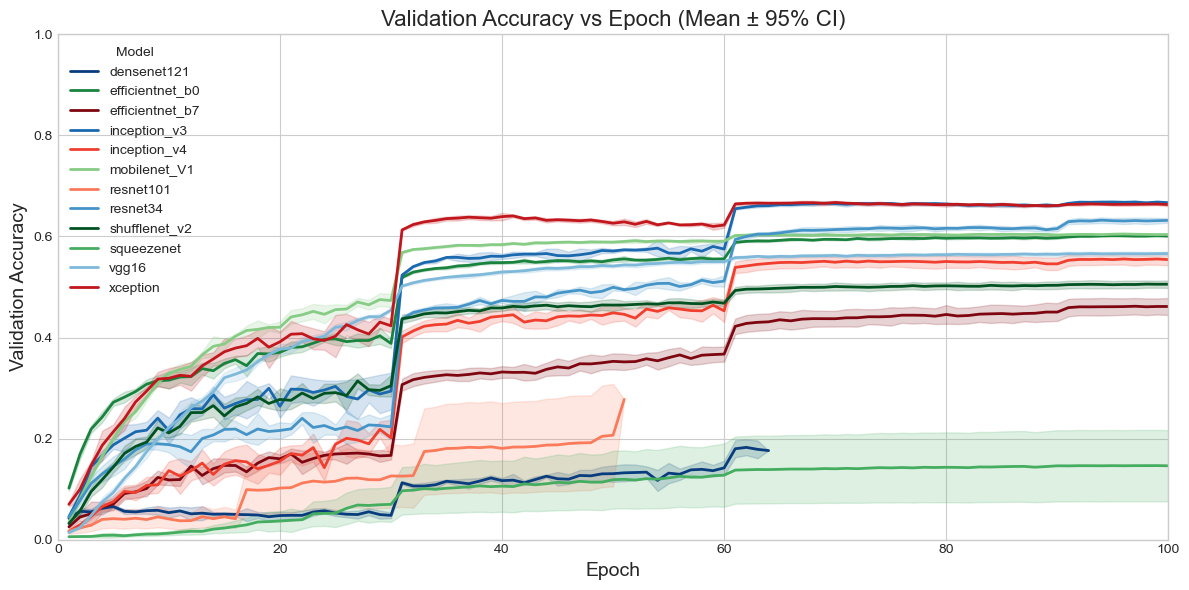

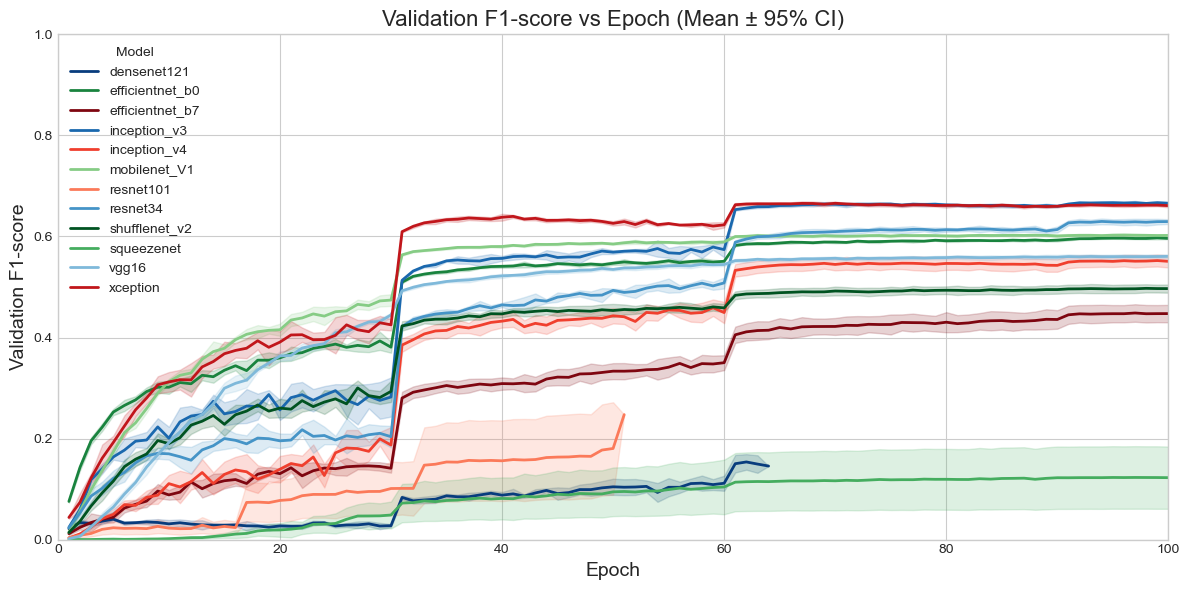

In [113]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def plot_metric_with_ci(
    df, metric_mean, metric_ci, ylabel, title, filename,
    legend_title="Model"
):
    plt.figure(figsize=(12, 6))

    plt.ylim(0, 1)
    plt.xlim(0, df['epoch'].max())

    model_order = sorted(df['model'].unique(), key=lambda m: m)

    for model in model_order:
        subset = df[df['model'] == model]

        color = model_colors[model]

        plt.plot(
            subset['epoch'],
            subset[metric_mean],
            linewidth=2,
            color=color,
            label=model  
        )

        plt.fill_between(
            subset['epoch'],
            subset[metric_mean] - subset[metric_ci],
            subset[metric_mean] + subset[metric_ci],
            alpha=0.18,
            color=color
        )

    plt.title(title, fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)


    plt.legend(
        title=legend_title,
        loc='upper left',
        fontsize=10
    )

    plt.tight_layout()

    plt.savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")

    plt.show()




plot_metric_with_ci(
    agg_df,
    metric_mean="val_acc_mean",
    metric_ci="val_acc_ci95",
    ylabel="Validation Accuracy",
    title="Validation Accuracy vs Epoch (Mean ± 95% CI)",
    filename="reports/results/accuracy_vs_epoch"
)

plot_metric_with_ci(
    agg_df,
    metric_mean="val_f1_mean",
    metric_ci="val_f1_ci95",
    ylabel="Validation F1-score",
    title="Validation F1-score vs Epoch (Mean ± 95% CI)",
    filename="reports/results/f1_vs_epoch"
)


## Best Epoch Performance

To compare models fairly, we extract:

- the best accuracy achieved in any epoch,

- the best F1-score,

- and the corresponding epoch.

This is done separately for each seed, allowing us to:

- measure variability across executions,

- compute mean ± 95% CI of the best values per model.

This step summarizes the actual achievable performance of each architecture, independent of the training dynamics.

In [115]:
import numpy as np

best_df = (
    logs_df.groupby(["model", "seed"])
    .agg(
        best_acc=("val_accuracy", "max"),
        best_f1=("val_f1", "max"),
    )
    .reset_index()
)

summary = (
    best_df.groupby("model")
    .agg(
        acc_mean=("best_acc", "mean"),
        acc_std=("best_acc", "std"),
        f1_mean=("best_f1", "mean"),
        f1_std=("best_f1", "std"),
        n=("best_acc", "count"),
    )
    .reset_index()
)

summary["acc_ci95"] = 1.96 * summary["acc_std"] / np.sqrt(summary["n"])
summary["f1_ci95"]  = 1.96 * summary["f1_std"]  / np.sqrt(summary["n"])

summary

,model,acc_mean,acc_std,f1_mean,f1_std,n,acc_ci95,f1_ci95
0,densenet121,0.18388,0.016721,0.15446,0.016549,5,0.014657,0.014506
1,efficientnet_b0,0.60270,0.002299,0.59822,0.002459,5,0.002015,0.002155
2,efficientnet_b7,0.46314,0.018882,0.44906,0.020013,5,0.016551,0.017542
3,inception_v3,0.67012,0.002818,0.66880,0.002850,5,0.002470,0.002499
4,inception_v4,0.55650,0.012110,0.55298,0.013035,5,0.010615,0.011425
5,mobilenet_V1,0.60586,0.002523,0.60400,0.002425,5,0.002212,0.002125
6,resnet101,0.20714,0.116181,0.18090,0.104912,5,0.101837,0.091960
7,resnet34,0.63270,0.006136,0.63046,0.006131,5,0.005379,0.005374
8,shufflenet_v2,0.50640,0.008608,0.49800,0.009666,5,0.007545,0.008473
9,squeezenet,0.14714,0.080626,0.12338,0.070793,5,0.070672,0.062052


## GPU Resource Metrics (Mean Across Runs)

Hardware-level metrics such as GPU utilization, memory usage and temperature
are inherently noisy even under identical configurations, due to effects such as
kernel scheduling, cooling control loops and driver-level activity. For these
signals, confidence intervals become visually dominant without adding much
interpretive value. 

To focus on deployment-relevant behavior, we report the **mean value across
the five executions** for each model and epoch, comparing the evolution of:
- average GPU utilization,
- average GPU memory usage (VRAM),
- average GPU temperature.



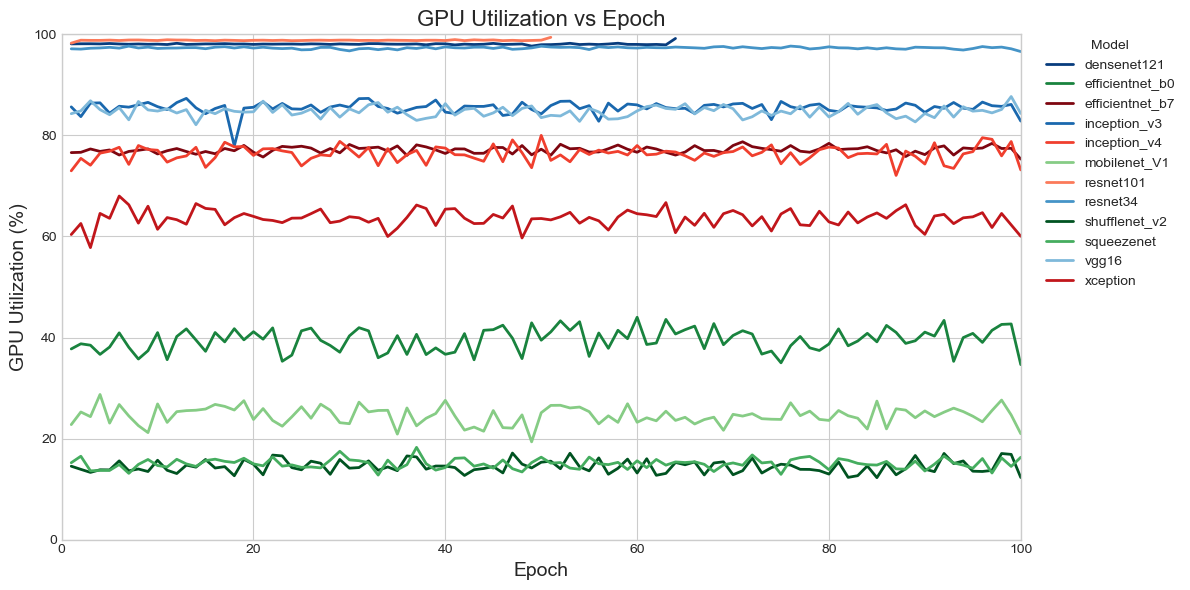

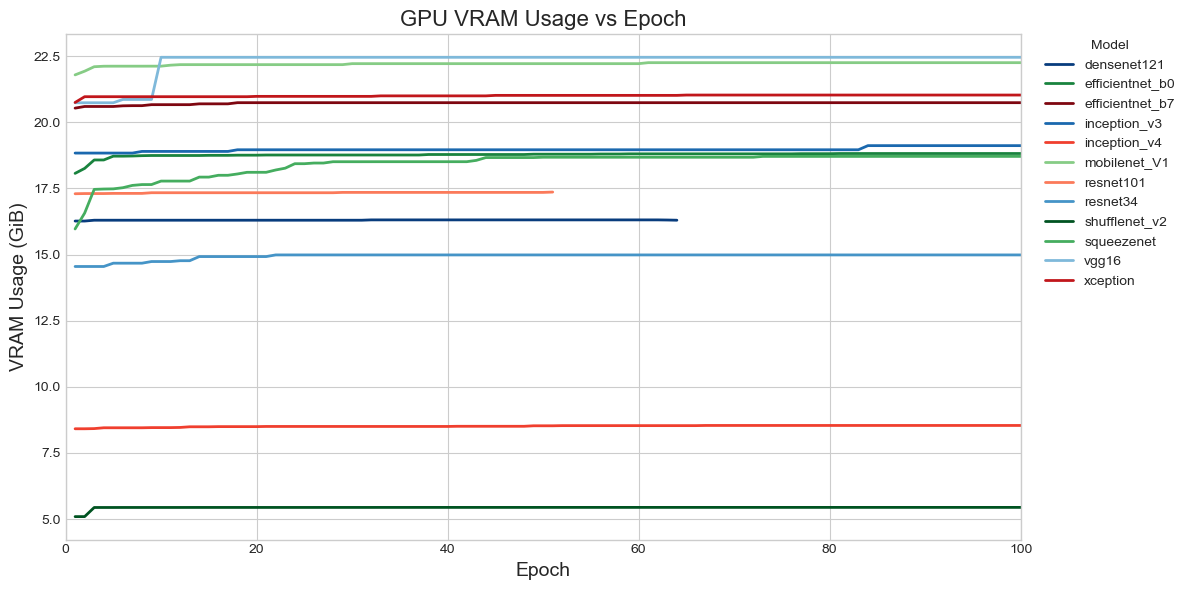

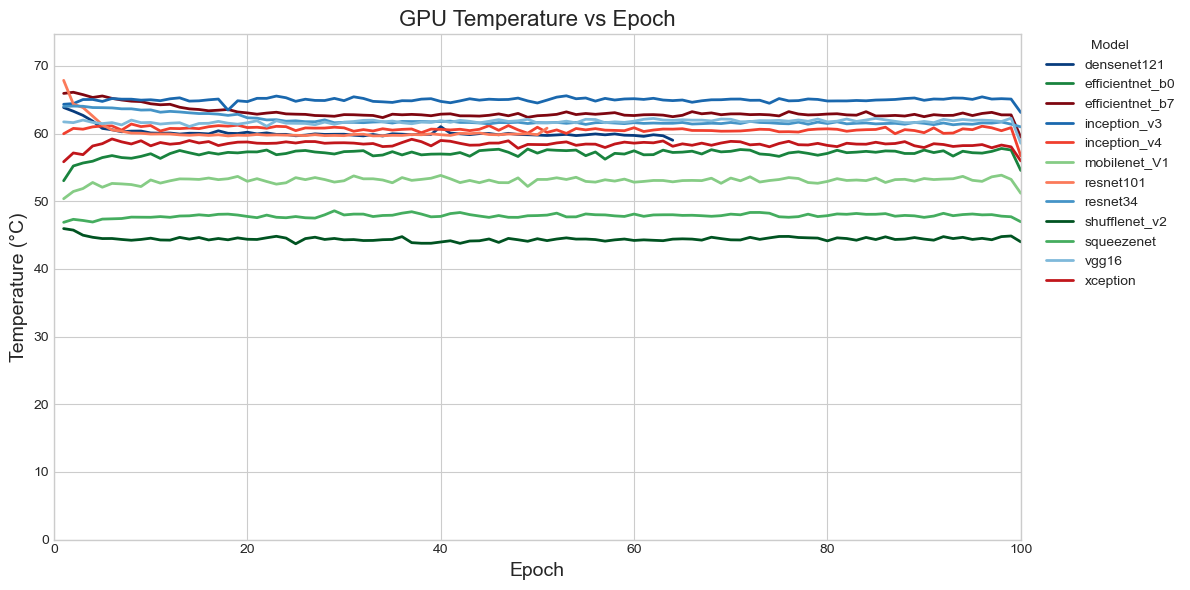

In [117]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


eff_df = (
    logs_df.groupby(["model", "epoch"])
    .agg(
        gpu_util_mean=("gpu_util_percent_avg", "mean"),
        gpu_vram_mean=("gpu_vram_used_bytes", "mean"),
        gpu_temp_mean=("gpu_temp_celsius_avg", "mean"),
    )
    .reset_index()
)


def plot_gpu_metric(
    df,
    metric,
    ylabel,
    title,
    filename,
    convert_vram=False
):
    plt.figure(figsize=(12, 6))

    if metric == "gpu_util_mean":
        plt.ylim(0, 100)
    elif metric == "gpu_temp_mean":
        plt.ylim(0, df[metric].max() * 1.1)

    plt.xlim(0, df["epoch"].max())

    for model in df["model"].unique():
        subset = df[df["model"] == model]

        y = subset[metric]
        if convert_vram:
            y = y / (1024**3)

        plt.plot(
            subset["epoch"],
            y,
            color=model_colors[model],
            linewidth=2,
            label=model
        )

    plt.title(title, fontsize=16)
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    plt.legend(
        title="Model",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=10
    )

    plt.tight_layout()

    plt.savefig(f"reports/results/{filename}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"reports/results/{filename}.pdf", bbox_inches="tight")

    plt.show()



plot_gpu_metric(
    eff_df,
    metric="gpu_util_mean",
    ylabel="GPU Utilization (%)",
    title="GPU Utilization vs Epoch",
    filename="gpu_utilization"
)

plot_gpu_metric(
    eff_df,
    metric="gpu_vram_mean",
    ylabel="VRAM Usage (GiB)",
    title="GPU VRAM Usage vs Epoch",
    filename="gpu_vram_usage",
    convert_vram=True
)

plot_gpu_metric(
    eff_df,
    metric="gpu_temp_mean",
    ylabel="Temperature (°C)",
    title="GPU Temperature vs Epoch",
    filename="gpu_temperature"
)


## Training Time Analysis

This section evaluates the computational cost of each CNN architecture by analyzing training time.  
Since our logs contain per-epoch timing (`elapsed_time_seconds`), the total training time for each run is obtained by summing the epoch durations for each `(model, seed)` pair.

This analysis provides insights into:

- how fast each architecture trains,
- the variability of training time across different random seeds,
- the trade-off between training cost and model performance.

The plots below summarize the distribution of total training time and the per-epoch timing behavior for each model.
ity.

              model  seed  training_time_total
0       densenet121    42            83101.600
1       densenet121    52            83443.682
2       densenet121    62            83437.411
3       densenet121    72            83247.012
4       densenet121    82            82583.607
5   efficientnet_b0    42             5315.345
6   efficientnet_b0    52             5374.714
7   efficientnet_b0    62             5306.088
8   efficientnet_b0    72             6150.628
9   efficientnet_b0    82             6143.711
10  efficientnet_b7    42            26512.738
11  efficientnet_b7    52            38087.822
12  efficientnet_b7    62            38341.990
13  efficientnet_b7    72            37634.461
14  efficientnet_b7    82            26417.237
15     inception_v3    42            23330.385
16     inception_v3    52            23164.583
17     inception_v3    62            22696.475
18     inception_v3    72            23279.967
19     inception_v3    82            23140.838
20     incept

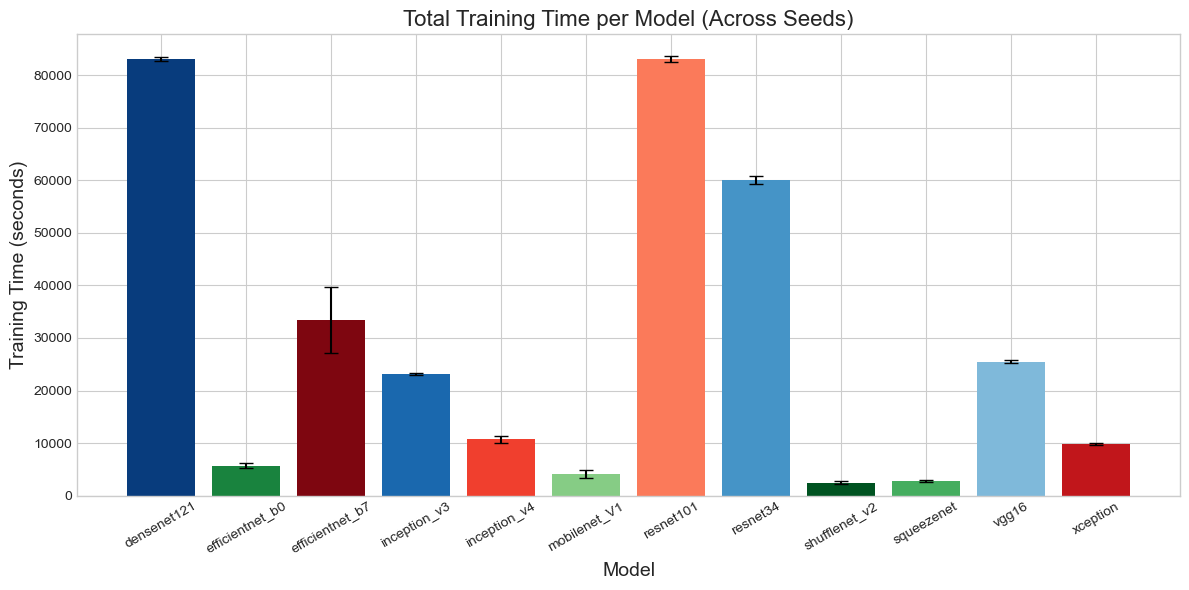

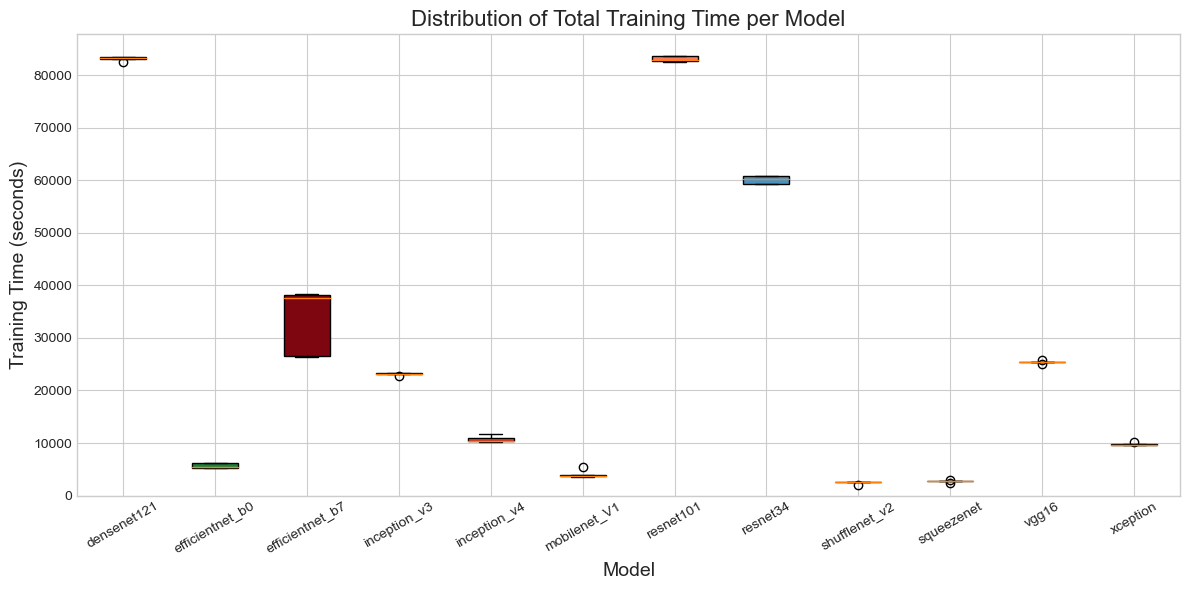

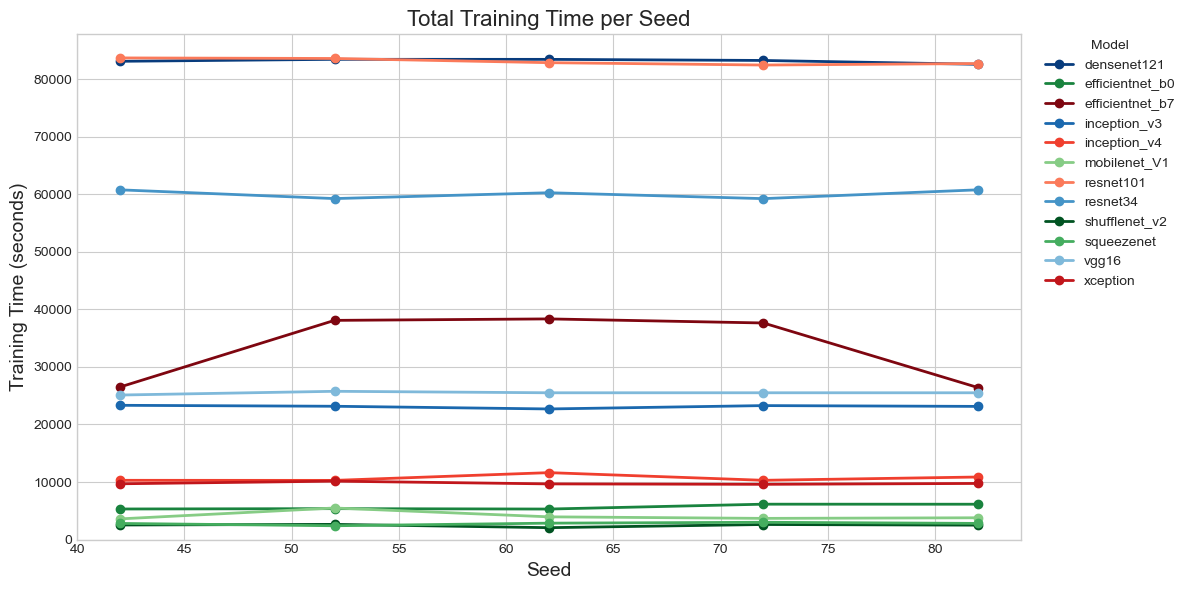

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")



run_times = (
    logs_df
    .groupby(["model", "seed"], as_index=False)
    .agg(training_time_total=("training_time_seconds", "sum"))
)

print(run_times)



available_models = run_times["model"].unique()

for m in available_models:
    if m not in model_colors:
        print(f"[AVISO] Modelo '{m}' não estava no model_colors. Atribuindo cor automática.")
        model_colors[m] = plt.cm.tab10(len(model_colors) % 10)



fig = plt.figure(figsize=(12, 6))

models = available_models
means = [run_times[run_times.model == m]["training_time_total"].mean() for m in models]
stds  = [run_times[run_times.model == m]["training_time_total"].std()  for m in models]
colors = [model_colors[m] for m in models]

plt.bar(models, means, yerr=stds, capsize=5, color=colors)

plt.title("Total Training Time per Model (Across Seeds)", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Training Time (seconds)", fontsize=14)
plt.xticks(rotation=30)
plt.ylim(bottom=0)   # escala absoluta

plt.tight_layout()
plt.savefig("reports/results/training_time_total_bar.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/training_time_total_bar.pdf", bbox_inches="tight")
plt.show()



fig = plt.figure(figsize=(12, 6))

positions = np.arange(len(models))
data = [run_times[run_times.model == m]["training_time_total"] for m in models]

box = plt.boxplot(
    data,
    positions=positions,
    patch_artist=True
)

for patch, m in zip(box['boxes'], models):
    patch.set_facecolor(model_colors[m])

plt.xticks(positions, models, rotation=30)
plt.title("Distribution of Total Training Time per Model", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Training Time (seconds)", fontsize=14)
plt.ylim(bottom=0)

plt.tight_layout()
plt.savefig("reports/results/training_time_boxplot.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/training_time_boxplot.pdf", bbox_inches="tight")
plt.show()



fig = plt.figure(figsize=(12, 6))

for m in models:
    subset = run_times[run_times.model == m]
    plt.plot(
        subset["seed"],
        subset["training_time_total"],
        marker="o",
        linewidth=2,
        color=model_colors[m],
        label=m
    )

plt.title("Total Training Time per Seed", fontsize=16)
plt.xlabel("Seed", fontsize=14)
plt.ylabel("Training Time (seconds)", fontsize=14)
plt.ylim(bottom=0)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=10
)

plt.tight_layout()
plt.savefig("reports/results/training_time_per_seed.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/training_time_per_seed.pdf", bbox_inches="tight")
plt.show()


## Accuracy vs Cost Tradeoff

This section evaluates the relationship between training cost and predictive performance for each CNN architecture.  
For every model, we compute:

- the mean validation accuracy across all five executions;
- the mean total training time (sum of per-epoch durations for each run).

Plotting these two quantities provides a clear view of the tradeoff between
**model efficiency** (training time) and **model performance** (accuracy).

Models located in the upper-left region of the plot are preferable, as they deliver
higher accuracy with lower computational cost.

,model,mean_val_accuracy,mean_training_time
0,densenet121,0.18388,83162.6624
1,efficientnet_b0,0.60270,5658.0972
2,efficientnet_b7,0.46314,33398.8496
3,inception_v3,0.67012,23122.4496
4,inception_v4,0.55650,10677.2260
5,mobilenet_V1,0.60586,4102.2624
6,resnet101,0.20714,83061.1660
7,resnet34,0.63270,60057.2722
8,shufflenet_v2,0.50640,2474.5280
9,squeezenet,0.14714,2775.9506


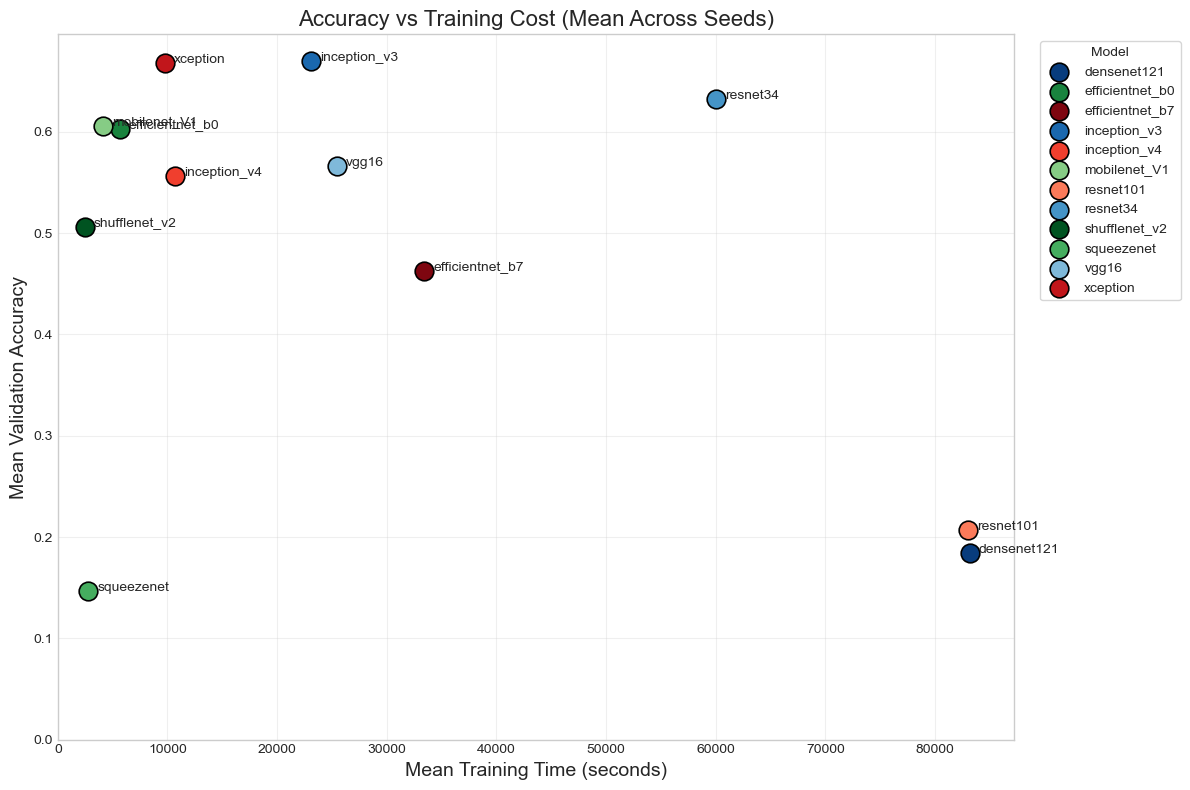

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")



acc_per_seed = (
    logs_df.groupby(["model", "seed"])["val_accuracy"]
           .max()
           .reset_index()
)

acc_mean = (
    acc_per_seed.groupby("model")["val_accuracy"]
                .mean()
                .reset_index()
                .rename(columns={"val_accuracy": "mean_val_accuracy"})
)

cost_mean = (
    run_times.groupby("model")["training_time_total"]
             .mean()
             .reset_index()
             .rename(columns={"training_time_total": "mean_training_time"})
)

tradeoff_df = pd.merge(acc_mean, cost_mean, on="model")
display(tradeoff_df)



fig = plt.figure(figsize=(12, 8))

for _, row in tradeoff_df.iterrows():
    plt.scatter(
        row["mean_training_time"],
        row["mean_val_accuracy"],
        s=180,
        color=model_colors[row["model"]],
        edgecolor="black",
        linewidth=1.2,
        label=row["model"]  # ainda será filtrado
    )

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

for _, row in tradeoff_df.iterrows():
    plt.text(
        row["mean_training_time"] + 0.01 * tradeoff_df["mean_training_time"].max(), 
        row["mean_val_accuracy"],
        row["model"],
        fontsize=10
    )

plt.title("Accuracy vs Training Cost (Mean Across Seeds)", fontsize=16)
plt.xlabel("Mean Training Time (seconds)", fontsize=14)
plt.ylabel("Mean Validation Accuracy", fontsize=14)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(alpha=0.3)

plt.legend(
    by_label.values(),
    by_label.keys(),
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

plt.savefig("reports/results/accuracy_vs_training_cost.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/accuracy_vs_training_cost.pdf", bbox_inches="tight")

plt.show()

### Overview of Categories
The models were organized into three main categories according to their architectural complexity and computational cost: lightweight, medium, and heavyweight. This division facilitates comparative analyses between groups and allows for a better interpretation of the trade-off between performance and cost in models with similar characteristics.

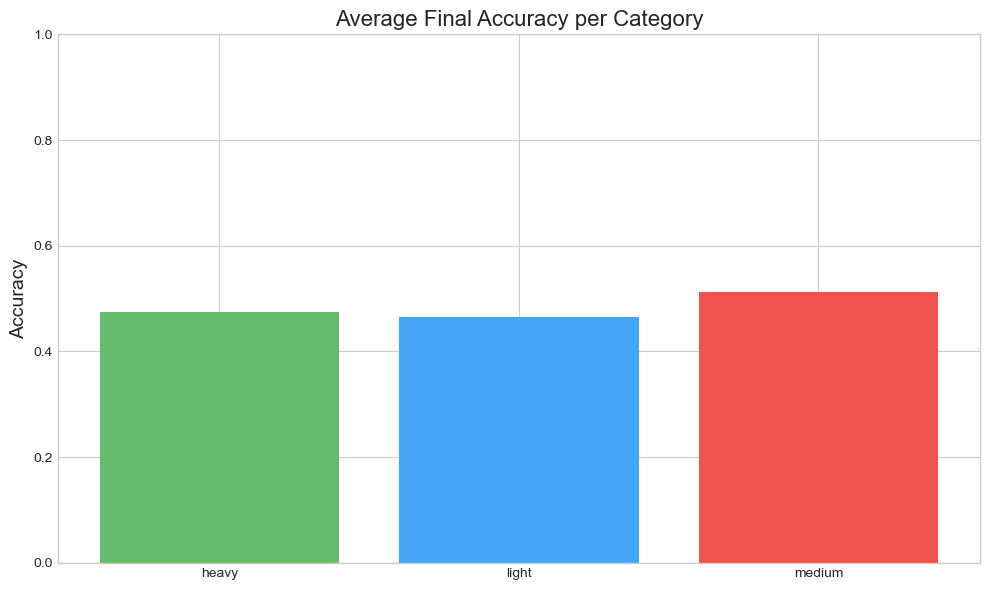

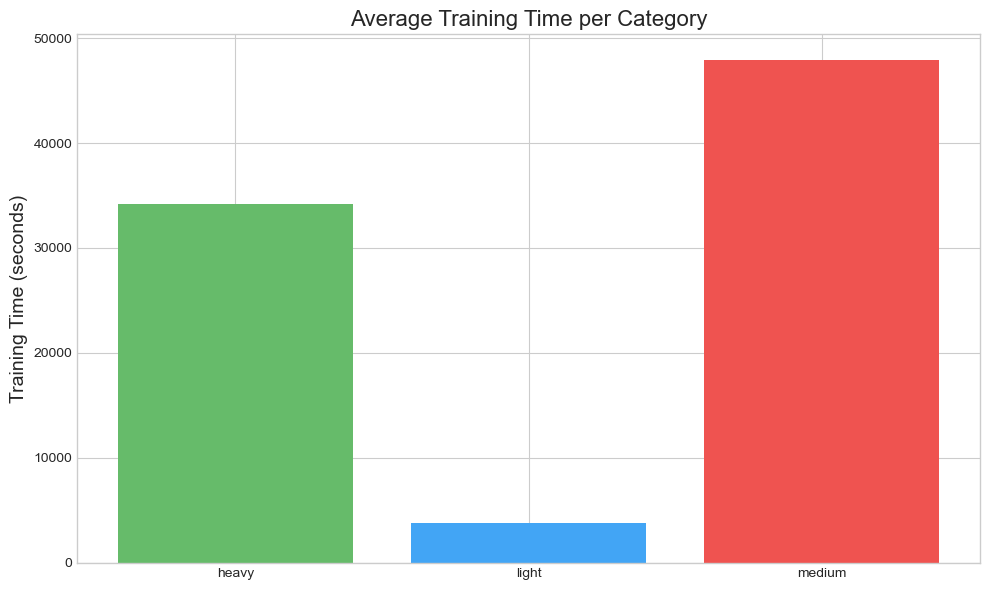

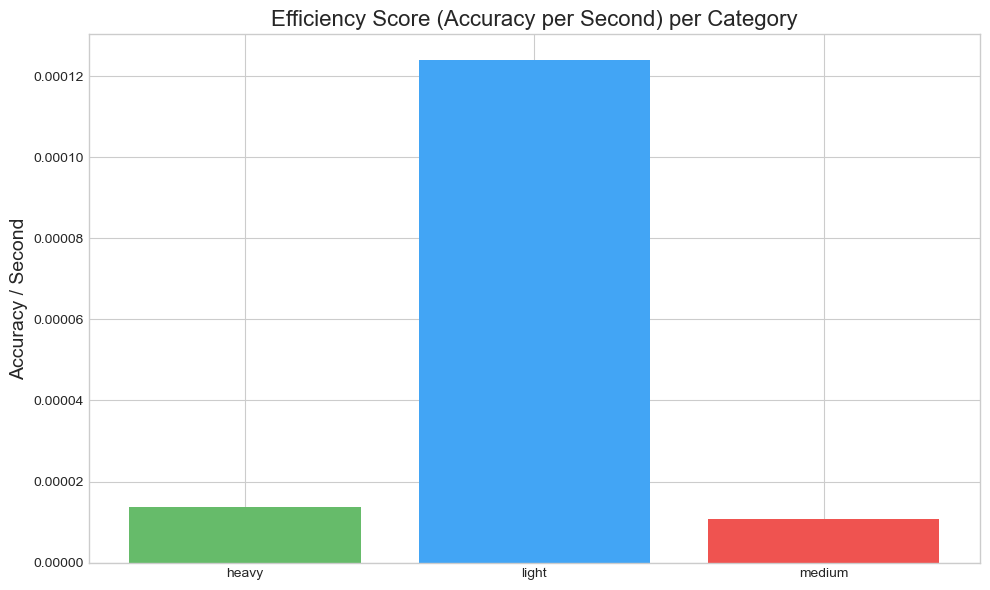

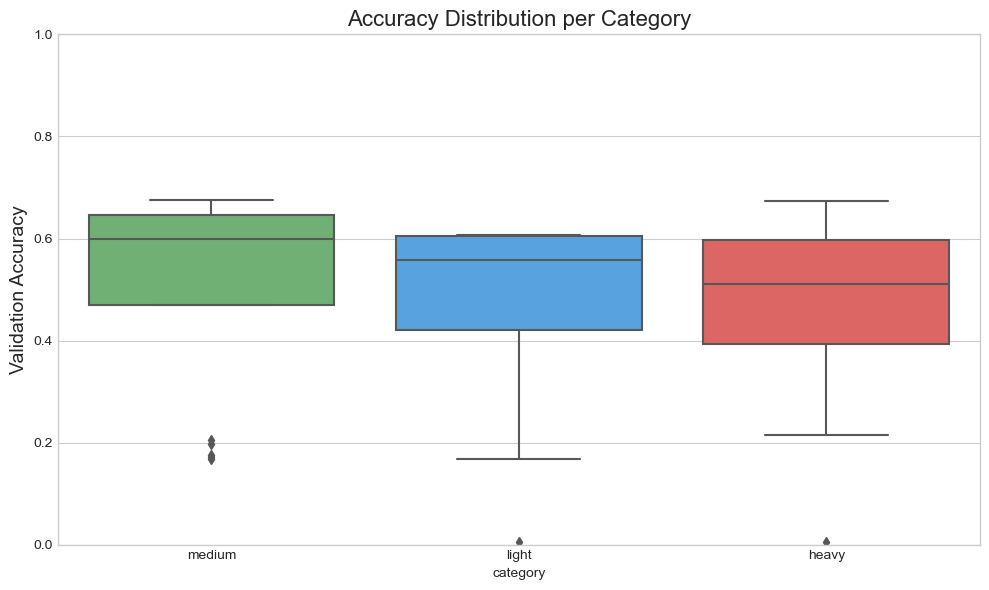

In [123]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")


model_to_category = {}
for cat, model_list in model_categories.items():
    for m in model_list:
        model_to_category[m] = cat

# adicionar categoria no dataframe
tradeoff_df["category"] = tradeoff_df["model"].map(model_to_category)
acc_per_seed["category"] = acc_per_seed["model"].map(model_to_category)
run_times["category"] = run_times["model"].map(model_to_category)



acc_cat = (
    acc_per_seed.groupby("category")["val_accuracy"]
                .mean()
                .reset_index()
)

fig = plt.figure(figsize=(10, 6))
plt.bar(
    acc_cat["category"],
    acc_cat["val_accuracy"],
    color=["#66bb6a", "#42a5f5", "#ef5350"]
)
plt.title("Average Final Accuracy per Category", fontsize=16)
plt.ylabel("Accuracy", fontsize=14)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("reports/results/cat_accuracy_mean.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/cat_accuracy_mean.pdf", bbox_inches="tight")
plt.show()




time_cat = (
    run_times.groupby("category")["training_time_total"]
             .mean()
             .reset_index()
)

fig = plt.figure(figsize=(10, 6))
plt.bar(
    time_cat["category"],
    time_cat["training_time_total"],
    color=["#66bb6a", "#42a5f5", "#ef5350"]
)
plt.title("Average Training Time per Category", fontsize=16)
plt.ylabel("Training Time (seconds)", fontsize=14)
plt.tight_layout()
plt.savefig("reports/results/cat_training_time.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/cat_training_time.pdf", bbox_inches="tight")
plt.show()



efficiency_cat = pd.merge(acc_cat, time_cat, on="category")
efficiency_cat["efficiency"] = (
    efficiency_cat["val_accuracy"] / efficiency_cat["training_time_total"]
)

fig = plt.figure(figsize=(10, 6))
plt.bar(
    efficiency_cat["category"],
    efficiency_cat["efficiency"],
    color=["#66bb6a", "#42a5f5", "#ef5350"]
)
plt.title("Efficiency Score (Accuracy per Second) per Category", fontsize=16)
plt.ylabel("Accuracy / Second", fontsize=14)
plt.tight_layout()
plt.savefig("reports/results/cat_efficiency.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/cat_efficiency.pdf", bbox_inches="tight")
plt.show()


fig = plt.figure(figsize=(10, 6))

sns.boxplot(
    data=acc_per_seed,
    x="category",
    y="val_accuracy",
    palette=["#66bb6a", "#42a5f5", "#ef5350"]
)

plt.title("Accuracy Distribution per Category", fontsize=16)
plt.ylabel("Validation Accuracy", fontsize=14)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("reports/results/cat_accuracy_distribution.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/results/cat_accuracy_distribution.pdf", bbox_inches="tight")
plt.show()